In [206]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pandas import CategoricalDtype
from pandas.core.dtypes.common import is_numeric_dtype, is_string_dtype

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary

In [207]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = "log1p_annual_medical_cost"

df[log_target] = np.log1p(df[target])

df["hospitalizations_grouped"] = df["hospitalizations_last_3yrs"].replace({
    2: "2+",
    3: "2+"
}).astype(str)

df["chronic_count_grouped"] = df["chronic_count"].apply(
    lambda x: str(x) if x <= 3 else "4+"
)

df["hospitalizations_grouped"] = pd.Categorical(
    df["hospitalizations_grouped"],
    categories=["0", "1", "2+"],
    ordered=True
)

df["chronic_count_grouped"] = pd.Categorical(
    df["chronic_count_grouped"],
    categories=["0", "1", "2", "3", "4+"],
    ordered=True
)

print("Shape:", df.shape)
display(df.head())
display(data_summary(df))

Shape: (100000, 57)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,1,0,2,0,1,0,0,8.844922,0,1
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,0,1,0,1,1,0,7.398548,0,2
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,1,0,2,1,0,1,0,8.944030,0,3
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,1,0,0,1,0,0,0,8.543108,0,1
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,2,0,1,1,0,1,0,7.439401,0,2


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


In [208]:
engineered_columns = [
    "log1p_annual_medical_cost",
    "hospitalizations_grouped",
    "chronic_count_grouped",
    "high_cost_90",
    "high_cost_95",
    "high_cost_99"
]

leakage_or_outcome_columns = [
    "person_id",
    "annual_medical_cost",
    "total_claims_paid",
    "avg_claim_amount",
    "claims_count",
    "annual_premium",
    "monthly_premium"
]

excluded_columns = set(leakage_or_outcome_columns + engineered_columns)

diagnostic_features = [
    col for col in df.columns
    if col not in excluded_columns
]

numeric_features = [
    col for col in diagnostic_features
    if is_numeric_dtype(df[col])
]

categorical_features = [
    col for col in diagnostic_features
    if is_string_dtype(df[col]) or isinstance(df[col].dtype, CategoricalDtype)
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Categorical features:
['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']


In [209]:
corr_rows = []

for col in numeric_features:
    corr_rows.append({
        "feature": col,
        "spearman_with_cost": df[[col, target]].corr(method="spearman").iloc[0, 1],
        "spearman_with_log_cost": df[[col, log_target]].corr(method="spearman").iloc[0, 1]
    })

corr_table = (
    pd.DataFrame(corr_rows)
    .sort_values("spearman_with_log_cost", ascending=False)
    .round(4)
)

corr_table

,feature,spearman_with_cost,spearman_with_log_cost
18,risk_score,0.3628,0.3628
19,chronic_count,0.3399,0.3399
35,is_high_risk,0.2981,0.2981
5,visits_last_year,0.2056,0.2056
7,days_hospitalized_last_3yrs,0.1978,0.1978
6,hospitalizations_last_3yrs,0.1943,0.1943
20,hypertension,0.1791,0.1791
9,systolic_bp,0.1701,0.1701
0,age,0.1648,0.1648
36,had_major_procedure,0.1499,0.1499


In [210]:
def binned_target_summary(
        data: pd.DataFrame,
        feature_col: str,
        target_col: str,
        bins: int = 10
) -> pd.DataFrame:
    temp = data[[feature_col, target_col]].dropna().copy()

    bin_col = f"{feature_col}_bin"

    temp[bin_col] = pd.qcut(
        temp[feature_col],
        q=bins,
        duplicates="drop"
    )

    binned_summary = (
        temp.groupby(bin_col, observed=True)
        .agg(
            n=(target_col, "size"),
            mean=(target_col, "mean"),
            median=(target_col, "median"),
            p90=(target_col, lambda x: x.quantile(0.90)),
            p95=(target_col, lambda x: x.quantile(0.95))
        )
        .reset_index()
    )

    binned_summary["bin_midpoint"] = binned_summary[bin_col].map(
        lambda interval: interval.mid
    ).astype(float)

    return binned_summary

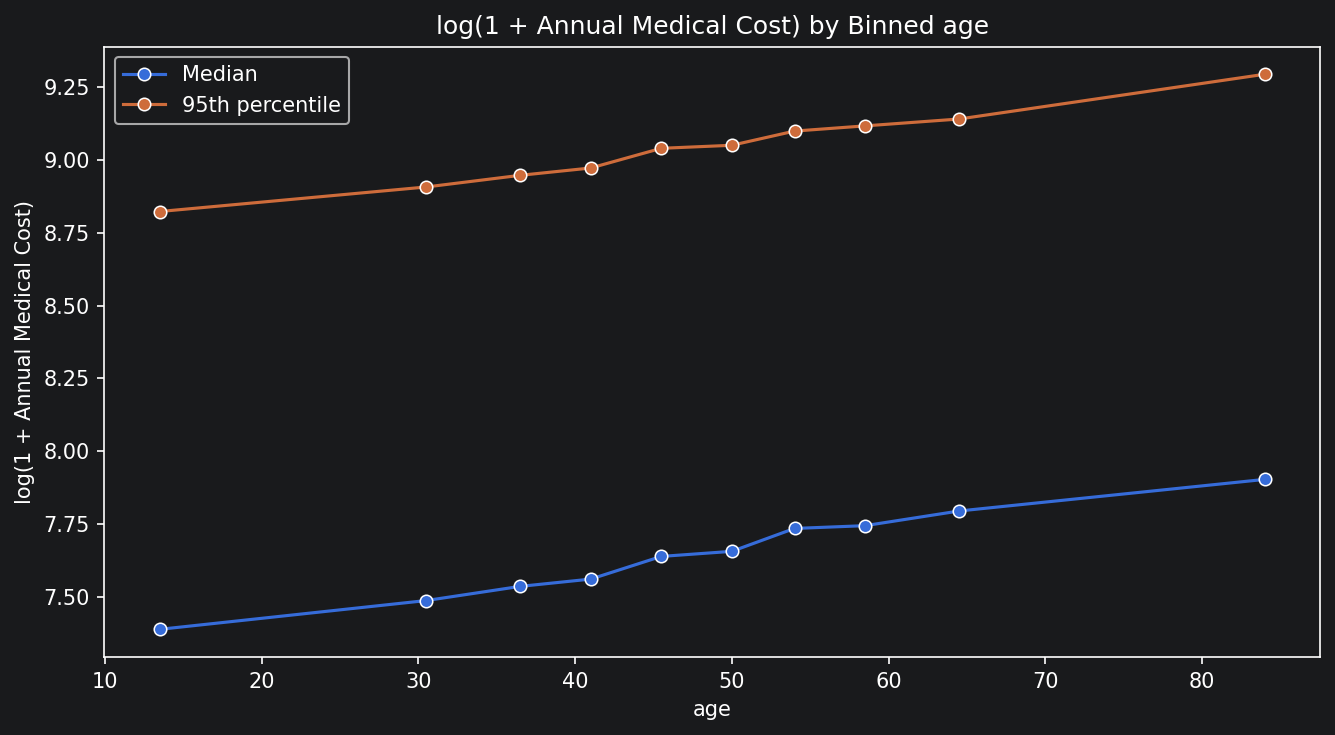

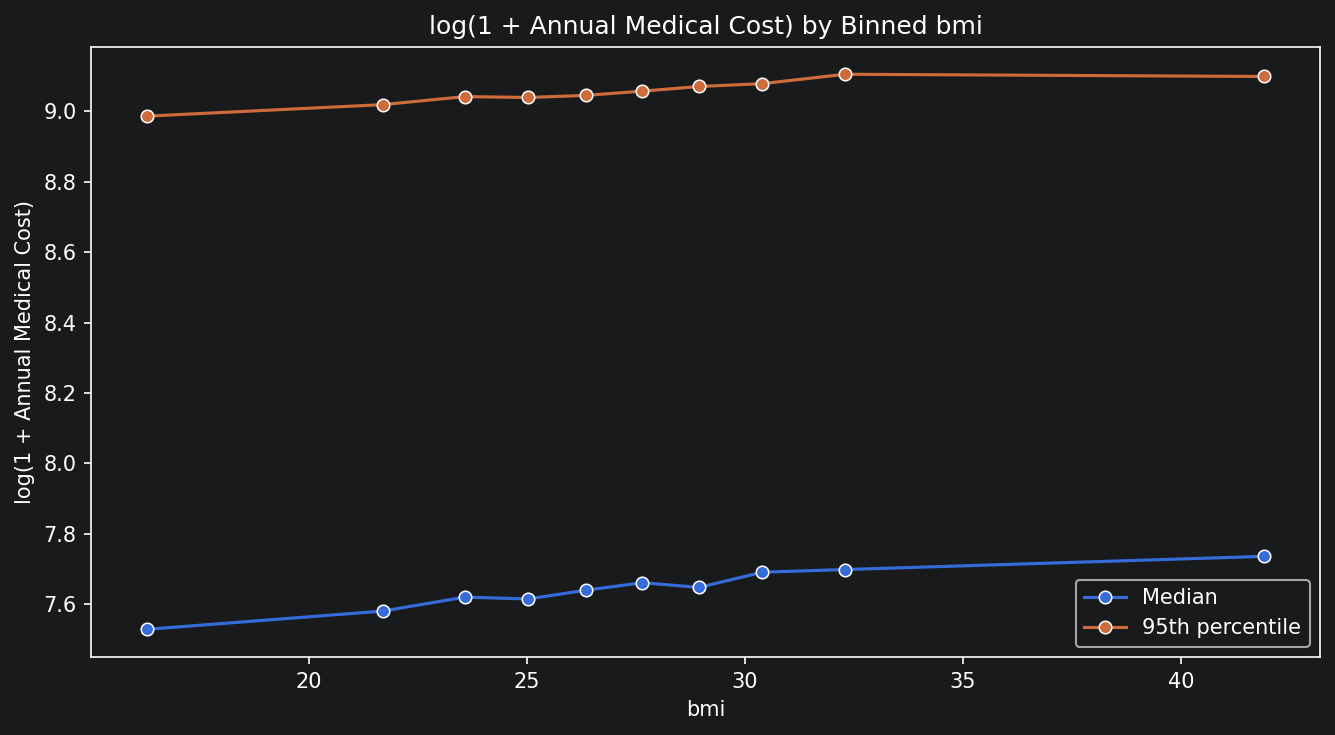

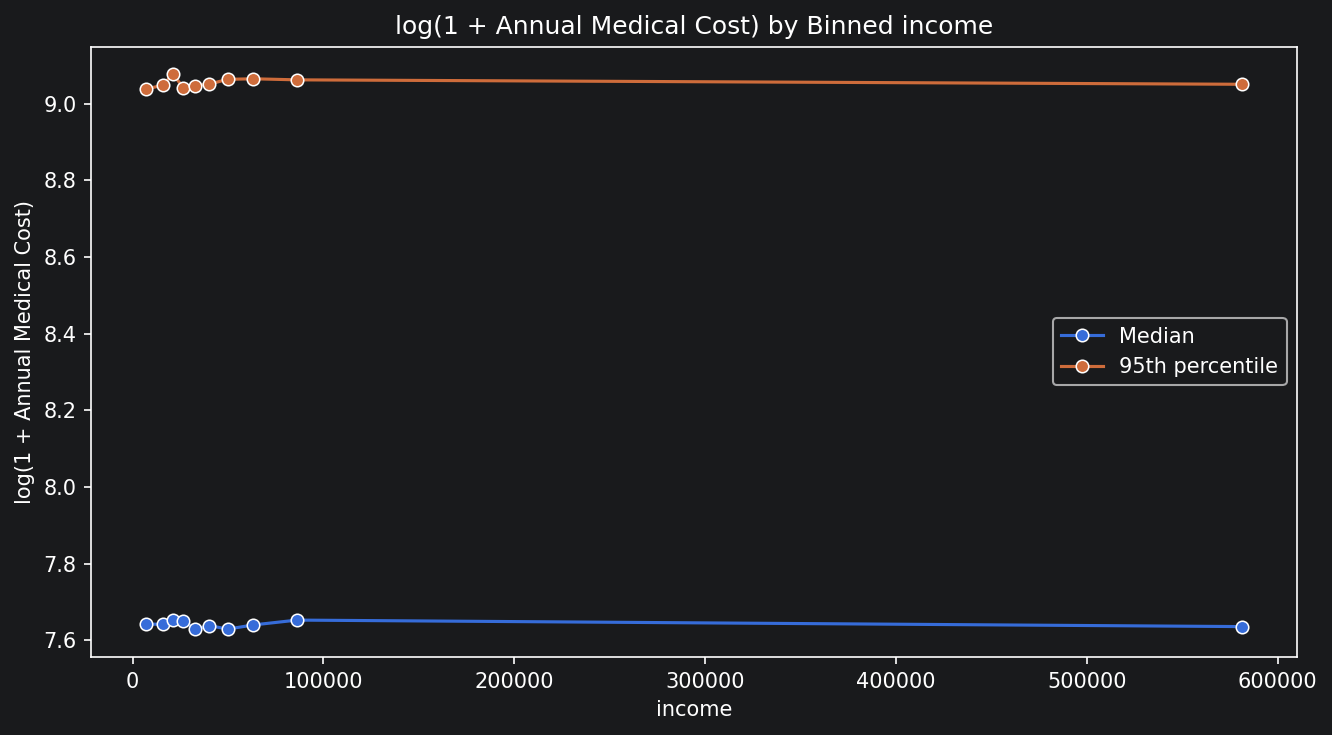

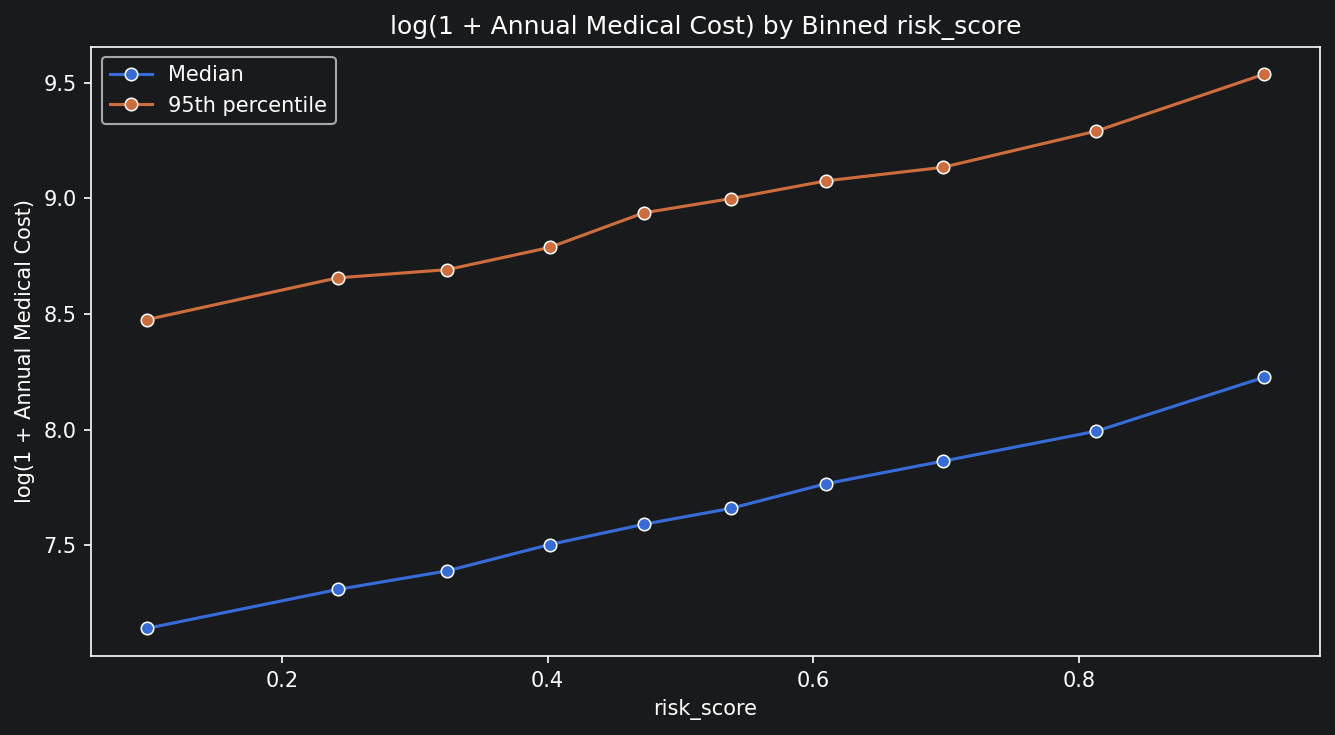

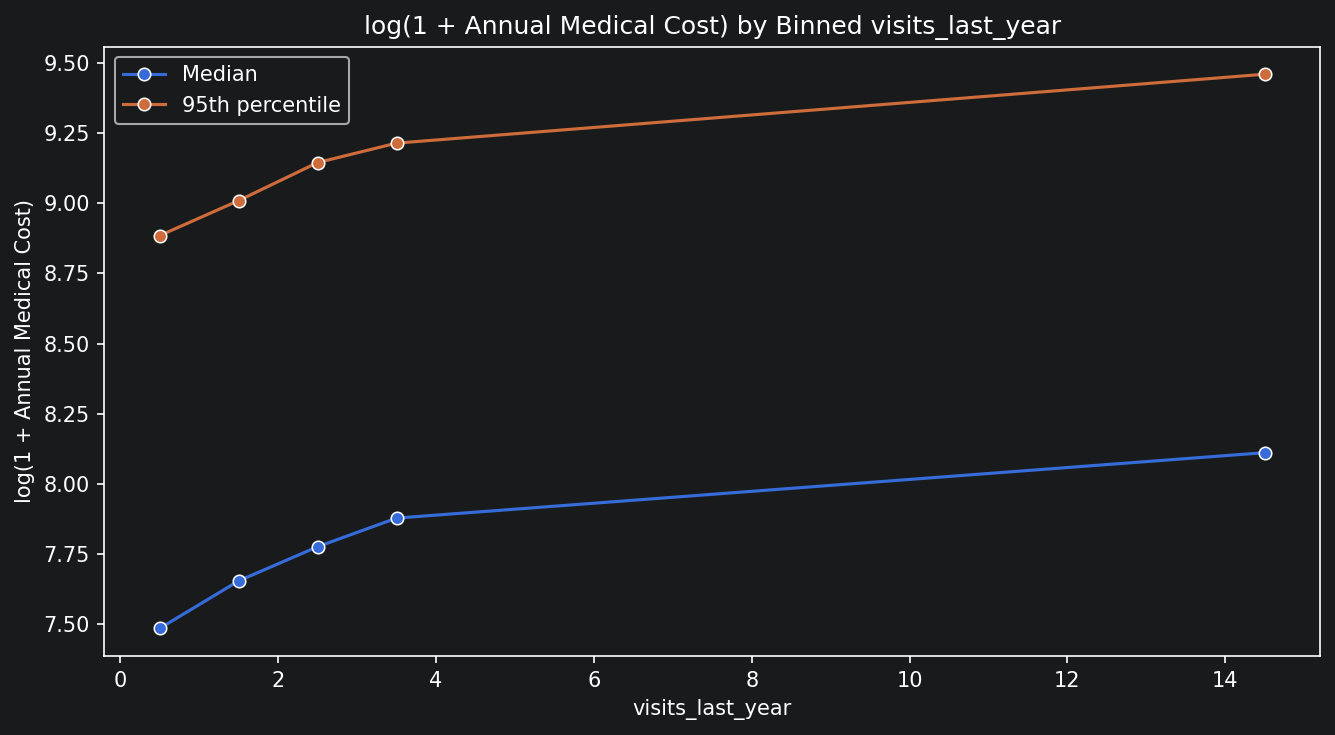

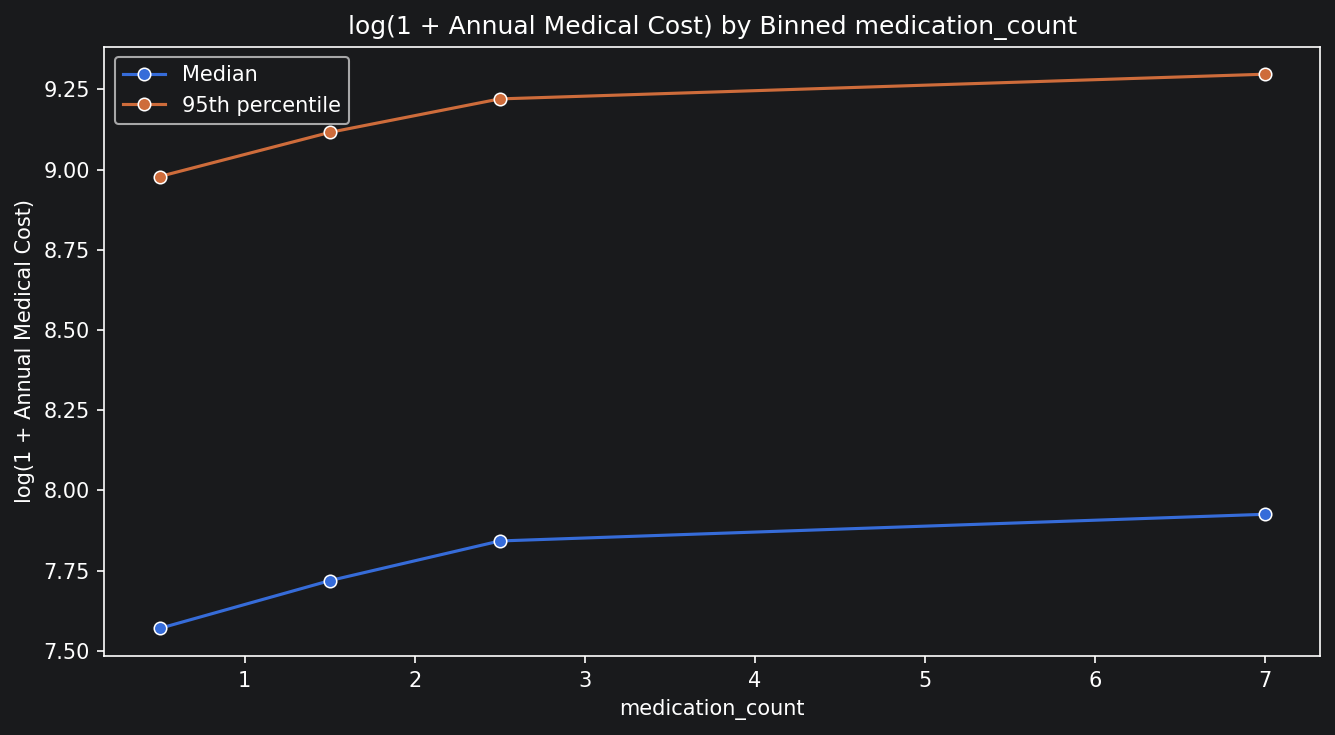

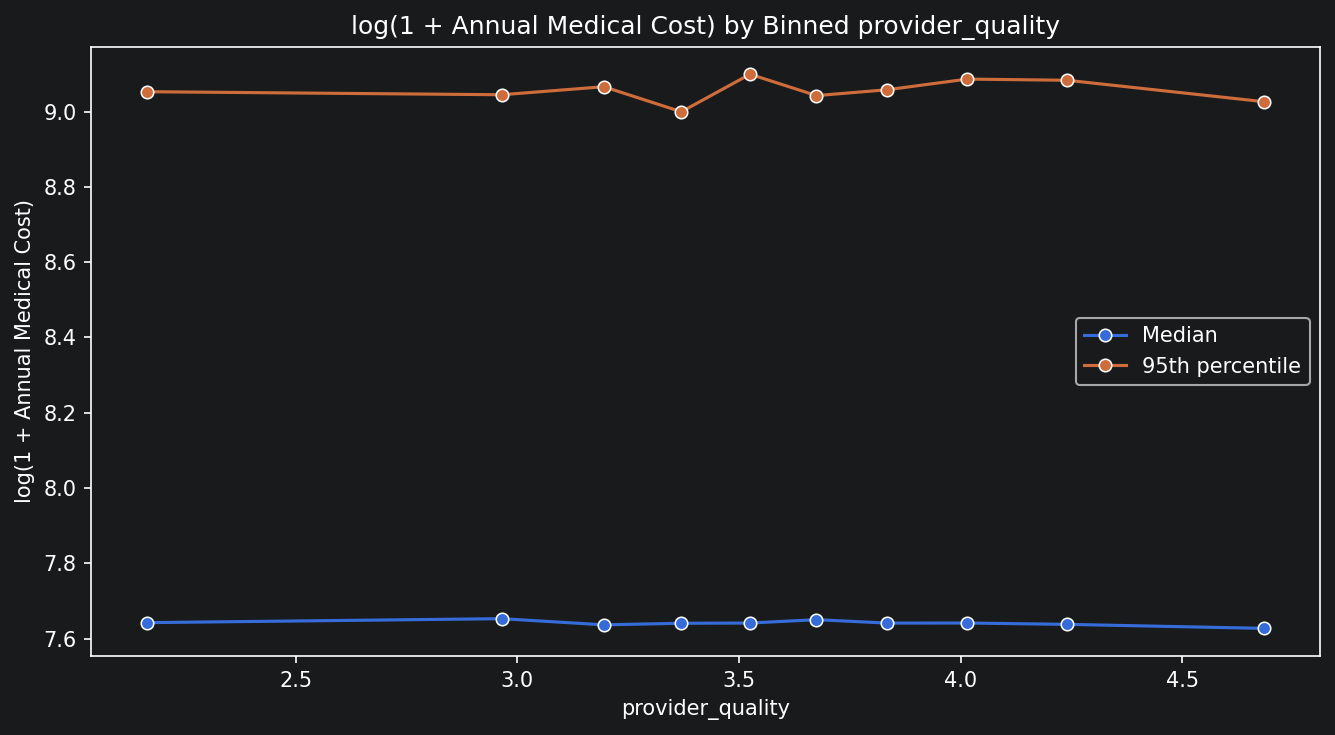

In [211]:
key_numeric_features = [
    "age",
    "bmi",
    "income",
    "risk_score",
    "visits_last_year",
    "medication_count",
    "provider_quality"
]

for feature in key_numeric_features:
    summary = binned_target_summary(df, feature, log_target)

    plt.figure(figsize=(9, 5), dpi=150)

    sns.lineplot(
        data=summary,
        x="bin_midpoint",
        y="median",
        marker="o",
        label="Median"
    )

    sns.lineplot(
        data=summary,
        x="bin_midpoint",
        y="p95",
        marker="o",
        label="95th percentile"
    )

    plt.title(f"log(1 + Annual Medical Cost) by Binned {feature}")
    plt.xlabel(feature)
    plt.ylabel("log(1 + Annual Medical Cost)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [212]:
df["days_hospitalized_grouped"] = df["days_hospitalized_last_3yrs"].apply(
    lambda x: "0" if x == 0 else "1-3" if x <= 3 else "4+"
)

df["days_hospitalized_grouped"] = pd.Categorical(
    df["days_hospitalized_grouped"],
    categories=["0", "1-3", "4+"],
    ordered=True
)

days_hospitalized_summary = (
    df.groupby("days_hospitalized_grouped", observed=True)
    .agg(
        n=(target, "size"),
        mean_cost=(target, "mean"),
        median_cost=(target, "median"),
        p90_cost=(target, lambda x: x.quantile(0.90)),
        p95_cost=(target, lambda x: x.quantile(0.95)),
        p99_cost=(target, lambda x: x.quantile(0.99))
    )
    .round(2)
)

display(days_hospitalized_summary)

,n,mean_cost,median_cost,p90_cost,p95_cost,p99_cost
days_hospitalized_grouped,,,,,,
0,91031,2810.44,1977.55,5794.89,7889.32,13910.33
1-3,3778,3948.33,2783.03,8104.42,10938.19,19498.08
4+,5191,5816.02,4274.31,11443.71,15598.54,26651.07


In [213]:
def categorical_target_summary(
        data: pd.DataFrame,
        feature_col: str,
        target_col: str
) -> pd.DataFrame:
    result = (
        data.groupby(feature_col, dropna=False)
        .agg(
            n=(target_col, "size"),
            mean=(target_col, "mean"),
            median=(target_col, "median"),
            p90=(target_col, lambda x: x.quantile(0.90)),
            p95=(target_col, lambda x: x.quantile(0.95)),
            p99=(target_col, lambda x: x.quantile(0.99))
        )
        .sort_values("median", ascending=False)
        .round(2)
    )

    return result

In [214]:
for categorical_col in categorical_features:
    print(f"\n{categorical_col}")
    display(categorical_target_summary(df, categorical_col, target))


sex


,n,mean,median,p90,p95,p99
sex,,,,,,
Male,48794,3019.94,2094.80,6244.90,8590.27,15348.25
Other,2013,2985.34,2080.72,6196.64,8720.83,15226.26
Female,49193,3000.03,2070.83,6206.97,8543.56,15274.05



region


,n,mean,median,p90,p95,p99
region,,,,,,
South,28029,3044.08,2100.56,6301.56,8860.03,15746.30
West,17879,3022.91,2095.87,6206.18,8660.49,15405.05
Central,12081,2968.24,2077.61,6105.76,8367.75,14485.47
North,22027,3002.01,2069.00,6210.24,8465.47,15349.85
East,19984,2981.96,2062.03,6239.30,8361.75,14718.04



urban_rural


...

,n,mean,median,p90,p95,p99
alcohol_freq,,,,,,
Daily,5006,3056.39,2147.93,6251.14,8677.05,14972.69
Weekly,19833,2990.26,2094.01,6156.40,8366.36,14804.55
NaN,30083,3016.14,2077.84,6254.09,8645.70,15691.58
Occasional,45078,3008.22,2072.58,6238.21,8600.60,15348.61



plan_type


,n,mean,median,p90,p95,p99
plan_type,,,,,,
POS,14989,3005.43,2100.15,6187.53,8459.13,15184.03
HMO,34723,3014.03,2083.32,6205.89,8620.13,15529.53
PPO,35167,3013.16,2082.83,6251.25,8587.95,15097.15
EPO,15121,2994.30,2063.94,6268.24,8489.35,15117.35



network_tier


,n,mean,median,p90,p95,p99
network_tier,,,,,,
Gold,19882,3004.41,2087.16,6180.52,8441.70,15293.46
Silver,40177,3014.97,2084.20,6268.30,8600.83,15250.25
Bronze,29932,3009.40,2082.61,6200.29,8595.43,15269.99
Platinum,10009,2997.49,2063.76,6215.08,8593.38,15464.52


In [215]:
p90 = df[target].quantile(0.90)
p95 = df[target].quantile(0.95)
p99 = df[target].quantile(0.99)

df["high_cost_90"] = (df[target] >= p90).astype(int)
df["high_cost_95"] = (df[target] >= p95).astype(int)
df["high_cost_99"] = (df[target] >= p99).astype(int)

print("90th percentile:", round(p90, 2))
print("95th percentile:", round(p95, 2))
print("99th percentile:", round(p99, 2))

90th percentile: 6227.09
95th percentile: 8570.35
99th percentile: 15293.68


In [216]:
tail_by_hospital = (
    df.groupby("hospitalizations_grouped", observed=True)
    .agg(
        n=("annual_medical_cost", "size"),
        mean_cost=("annual_medical_cost", "mean"),
        p95_cost=("annual_medical_cost", lambda x: x.quantile(0.95)),
        p99_cost=("annual_medical_cost", lambda x: x.quantile(0.99)),
        high_cost_95_rate=("high_cost_95", "mean"),
        high_cost_99_rate=("high_cost_99", "mean")
    )
    .round(4)
)

tail_by_hospital

,n,mean_cost,p95_cost,p99_cost,high_cost_95_rate,high_cost_99_rate
hospitalizations_grouped,,,,,,
0,91031,2810.4431,7889.320,13910.3260,0.0405,0.0072
1,8582,4919.6337,13216.472,23232.6995,0.1398,0.0351
2+,387,7461.1096,20864.746,30406.7422,0.2894,0.1163


In [217]:
tail_by_chronic = (
    df.groupby("chronic_count_grouped", observed=True)
    .agg(
        n=("annual_medical_cost", "size"),
        mean_cost=("annual_medical_cost", "mean"),
        p95_cost=("annual_medical_cost", lambda x: x.quantile(0.95)),
        p99_cost=("annual_medical_cost", lambda x: x.quantile(0.99)),
        high_cost_95_rate=("high_cost_95", "mean"),
        high_cost_99_rate=("high_cost_99", "mean")
    )
    .round(4)
)

tail_by_chronic

,n,mean_cost,p95_cost,p99_cost,high_cost_95_rate,high_cost_99_rate
chronic_count_grouped,,,,,,
0,46532,2176.3317,5949.5805,10487.0442,0.0187,0.0026
1,37579,3332.0129,9023.7080,15586.6164,0.0574,0.0106
2,13111,4438.1893,12001.3900,20854.2780,0.1106,0.0248
3,2452,5671.4266,15269.9545,26076.4563,0.1778,0.0498
4+,326,7260.6473,19244.6775,30407.0175,0.2761,0.0982


In [218]:
interaction_median = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc="median",
    observed=True
).round(2)

interaction_p95 = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc=lambda x: x.quantile(0.95),
    observed=True
).round(2)

interaction_p99 = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc=lambda x: x.quantile(0.99),
    observed=True
).round(2)

interaction_counts = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc="size",
    observed=True
)

display(interaction_median)
display(interaction_p95)
display(interaction_p99)
display(interaction_counts)

hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,1492.50,2893.87,4269.22
1,2307.82,3740.04,5249.40
2,3118.88,4532.38,6037.24
3,3926.81,5201.54,6995.92
4+,4681.58,6367.56,17772.25


hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,5439.79,10564.52,13609.73
1,8368.63,13528.17,22285.71
2,11258.44,15829.44,23355.06
3,14769.86,19509.05,24076.70
4+,18730.82,16942.82,20471.11


hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,9245.16,18793.92,19753.40
1,14058.35,22983.96,29767.32
2,19037.18,29144.84,36586.30
3,24852.89,26376.26,28668.77
4+,34556.66,26119.39,20837.82


hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,43031,3375,126
1,33987,3441,151
2,11639,1392,80
3,2092,334,26
4+,282,40,4


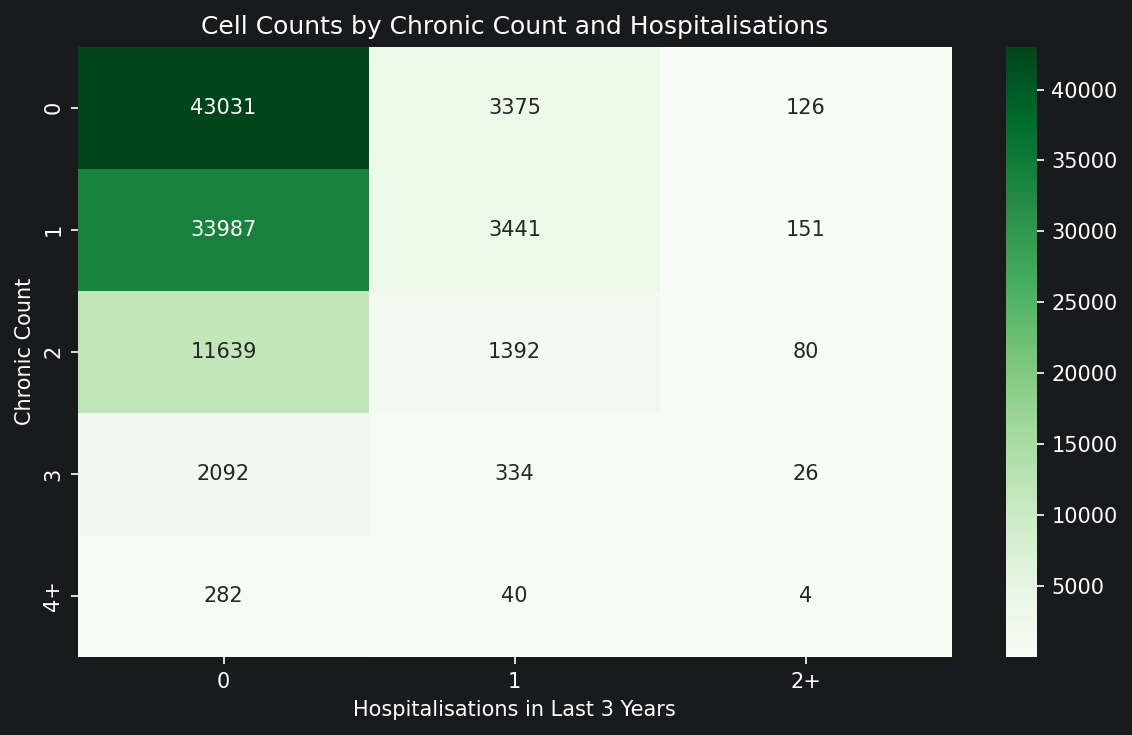

In [219]:
plt.figure(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_counts,
    annot=True,
    fmt=".0f",
    cmap="Greens"
)

plt.title("Cell Counts by Chronic Count and Hospitalisations")
plt.xlabel("Hospitalisations in Last 3 Years")
plt.ylabel("Chronic Count")
plt.tight_layout()
plt.show()

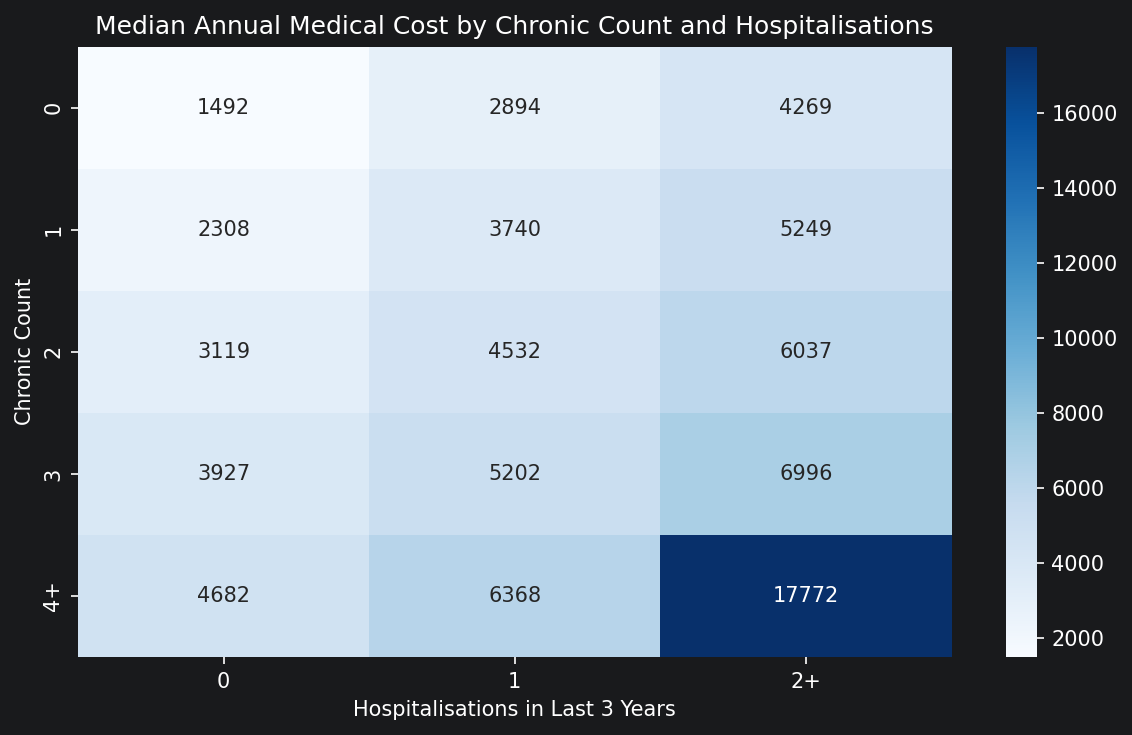

In [220]:
plt.figure(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_median,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Median Annual Medical Cost by Chronic Count and Hospitalisations")
plt.xlabel("Hospitalisations in Last 3 Years")
plt.ylabel("Chronic Count")
plt.tight_layout()
plt.show()

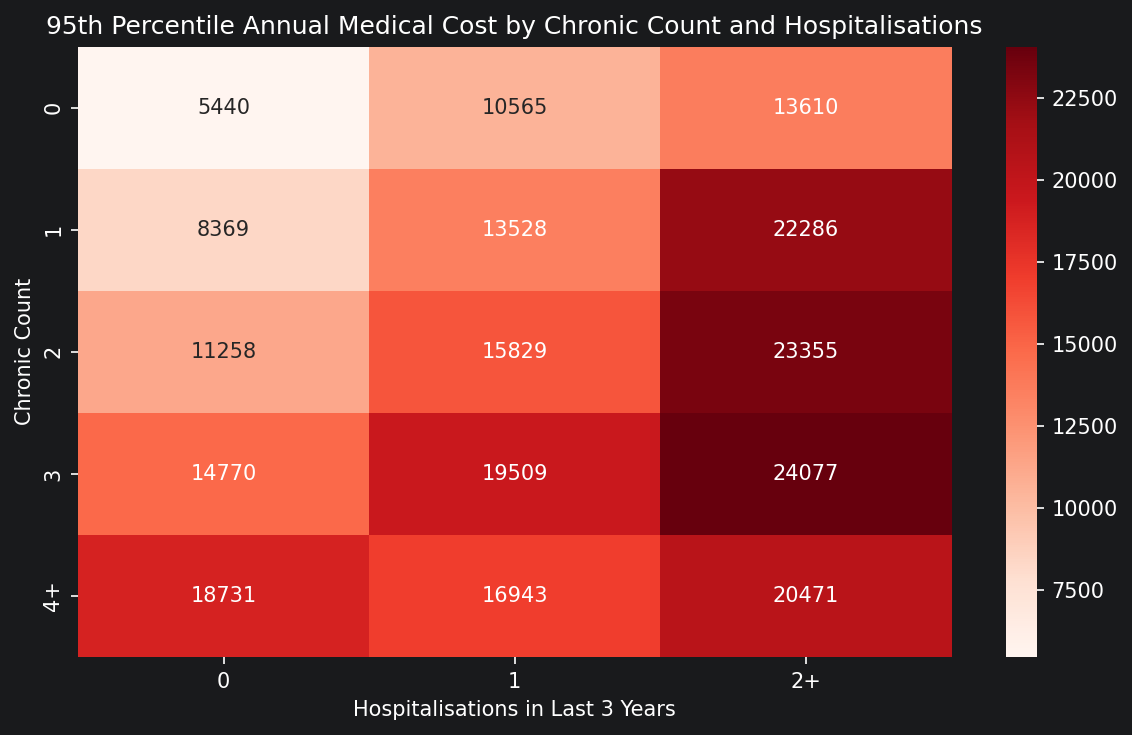

In [221]:
plt.figure(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_p95,
    annot=True,
    fmt=".0f",
    cmap="Reds"
)

plt.title("95th Percentile Annual Medical Cost by Chronic Count and Hospitalisations")
plt.xlabel("Hospitalisations in Last 3 Years")
plt.ylabel("Chronic Count")
plt.tight_layout()
plt.show()

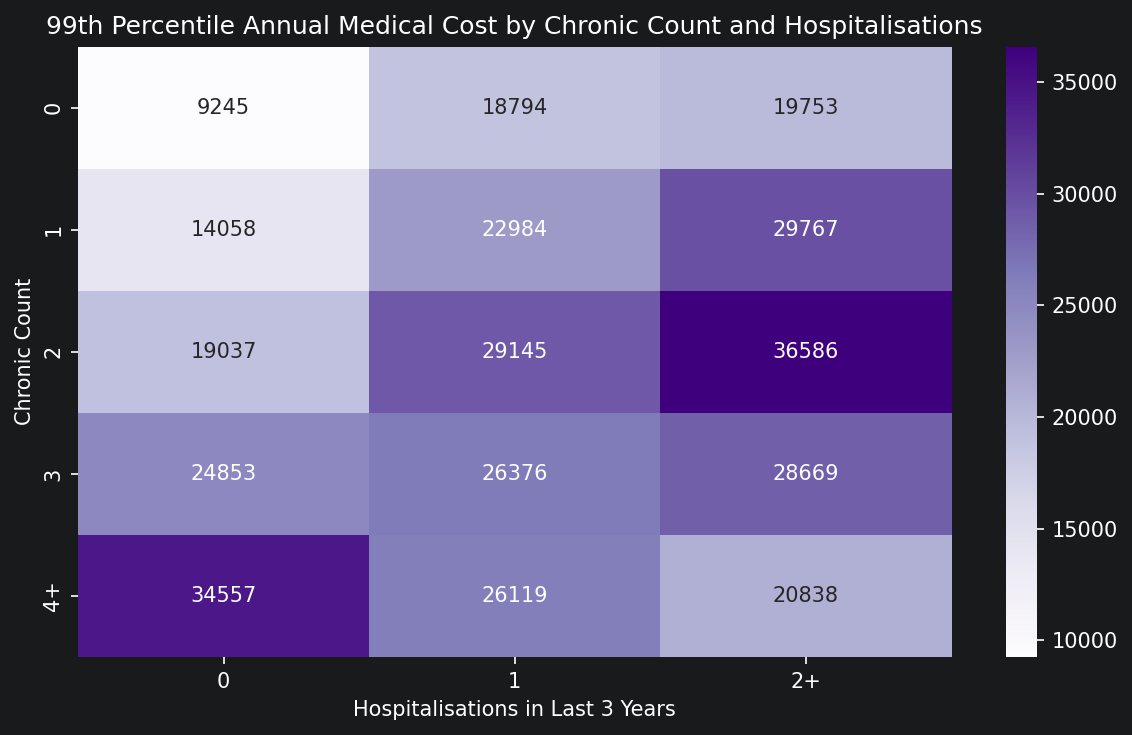

In [222]:
plt.figure(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_p99,
    annot=True,
    fmt=".0f",
    cmap="Purples"
)

plt.title("99th Percentile Annual Medical Cost by Chronic Count and Hospitalisations")
plt.xlabel("Hospitalisations in Last 3 Years")
plt.ylabel("Chronic Count")
plt.tight_layout()
plt.show()

In [223]:
df_sorted = df.sort_values(target, ascending=False).copy()

total_cost = df_sorted[target].sum()

tail_concentration = pd.DataFrame({
    "top_percent": [1, 2.5, 5, 10, 20],
    "n_policyholders": [
        int(len(df_sorted) * p / 100)
        for p in [1, 2.5, 5, 10, 20]
    ]
})

tail_concentration["cost_share"] = tail_concentration["n_policyholders"].apply(
    lambda n: df_sorted.head(n)[target].sum() / total_cost
)

tail_concentration["cost_share"] = tail_concentration["cost_share"].round(4)

tail_concentration

,top_percent,n_policyholders,cost_share
0,1.0,1000,0.0709
1,2.5,2500,0.1351
2,5.0,5000,0.2158
3,10.0,10000,0.3360
4,20.0,20000,0.5061


In [224]:
def mean_excess_table(data: pd.Series, quantiles=None) -> pd.DataFrame:
    if quantiles is None:
        quantiles = np.arange(0.80, 0.995, 0.01)

    rows = []

    for q in quantiles:
        threshold = data.quantile(q)
        excesses = data[data > threshold] - threshold

        rows.append({
            "quantile": q,
            "threshold": threshold,
            "n_exceedances": len(excesses),
            "mean_excess": excesses.mean()
        })

    return pd.DataFrame(rows)

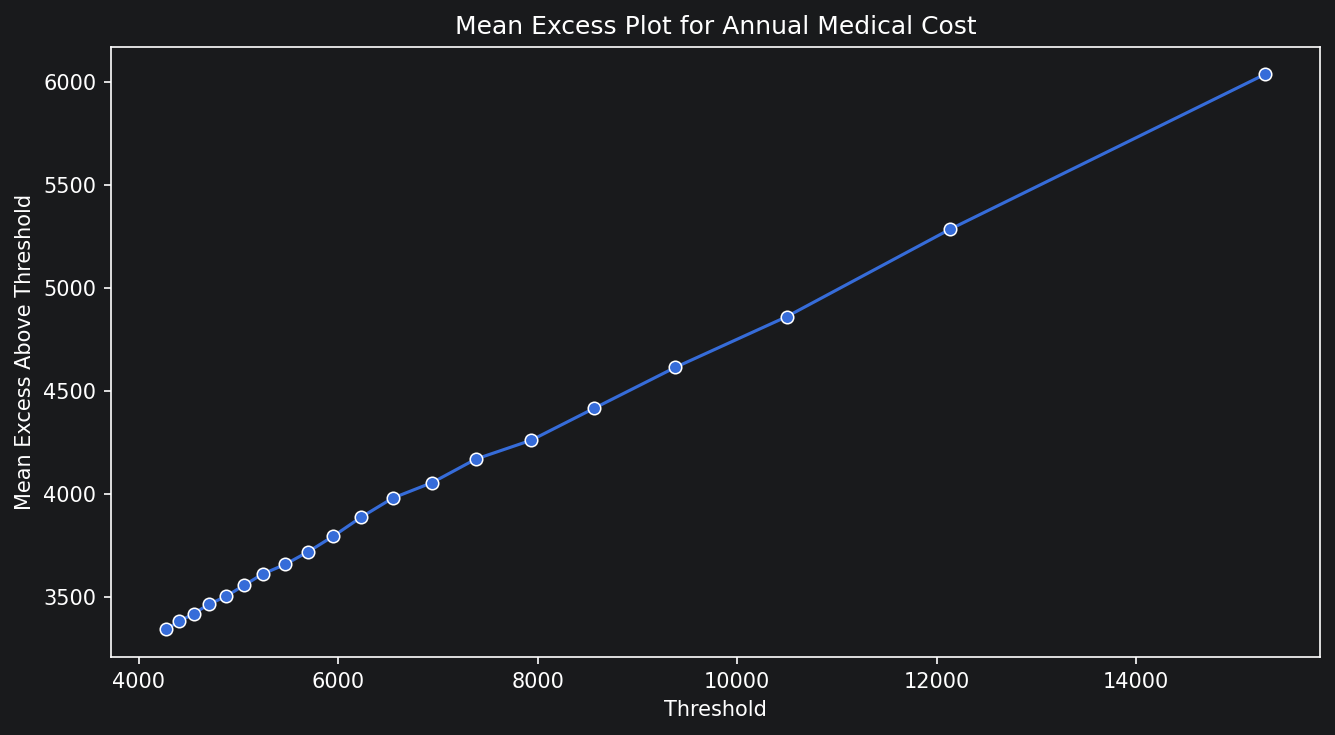

,quantile,threshold,n_exceedances,mean_excess
10,0.90,6227.0920,10000,3885.052012
11,0.91,6547.3269,9000,3979.088006
12,0.92,6944.3900,8000,4054.738756
13,0.93,7380.3400,6999,4168.591420
14,0.94,7936.4440,6000,4260.441255
15,0.95,8570.3505,5000,4416.414762
16,0.96,9380.9956,4000,4614.429685
17,0.97,10496.0623,3000,4860.472980
18,0.98,12131.4906,2000,5284.859200
19,0.99,15293.6822,1000,6039.087930


In [225]:
me_table = mean_excess_table(df[target])

plt.figure(figsize=(9, 5), dpi=150)

sns.lineplot(
    data=me_table,
    x="threshold",
    y="mean_excess",
    marker="o"
)

plt.title("Mean Excess Plot for Annual Medical Cost")
plt.xlabel("Threshold")
plt.ylabel("Mean Excess Above Threshold")
plt.tight_layout()
plt.show()

me_table.tail(10)

In [226]:
variance_by_hospital = (
    df.groupby("hospitalizations_grouped", observed=True)[target]
    .agg(
        n="size",
        mean="mean",
        std="std",
        median="median",
        iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    .round(2)
)

variance_by_hospital

,n,mean,std,median,iqr
hospitalizations_grouped,,,,,
0,91031,2810.44,2827.94,1977.55,2359.68
1,8582,4919.63,4685.89,3539.12,4104.35
2+,387,7461.11,7034.13,5108.38,6523.50


In [227]:
variance_by_chronic = (
    df.groupby("chronic_count_grouped", observed=True)[target]
    .agg(
        n="size",
        mean="mean",
        std="std",
        median="median",
        iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    .round(2)
)

variance_by_chronic

,n,mean,std,median,iqr
chronic_count_grouped,,,,,
0,46532,2176.33,2127.75,1558.97,1778.05
1,37579,3332.01,3171.20,2415.40,2705.87
2,13111,4438.19,4067.45,3249.83,3613.25
3,2452,5671.43,5338.14,4137.85,4349.46
4+,326,7260.65,7137.06,5260.05,6538.42
